# **Check data and modeling**

In [1]:
import pandas as pd

df = pd.read_csv('/content/telco_ml_features.csv')

print(df.shape)
print(df.head())

(7043, 15)
   customerid  gender  seniorcitizen partner dependents  tenure  \
0  7590-VHVEG  Female              0     Yes         No       1   
1  5575-GNVDE    Male              0      No         No      34   
2  3668-QPYBK    Male              0      No         No       2   
3  7795-CFOCW    Male              0      No         No      45   
4  9237-HQITU  Female              0      No         No       2   

  internetservice        contract              paymentmethod  monthlycharges  \
0             DSL  Month-to-month           Electronic check           29.85   
1             DSL        One year               Mailed check           56.95   
2             DSL  Month-to-month               Mailed check           53.85   
3             DSL        One year  Bank transfer (automatic)           42.30   
4     Fiber optic  Month-to-month           Electronic check           70.70   

   totalcharges  is_churned  tenure_group charge_bucket  baseline_risk_score  
0         29.85           

#Check data

In [2]:
df.dtypes

,0
customerid,object
gender,object
seniorcitizen,int64
partner,object
dependents,object
tenure,int64
internetservice,object
contract,object
paymentmethod,object
monthlycharges,float64


In [3]:
df.isnull().sum()

,0
customerid,0
gender,0
seniorcitizen,0
partner,0
dependents,0
tenure,0
internetservice,0
contract,0
paymentmethod,0
monthlycharges,0


In [4]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,internetservice,contract,paymentmethod,monthlycharges,totalcharges,is_churned,tenure_group,charge_bucket,baseline_risk_score
0,7590-VHVEG,Female,0,Yes,No,1,DSL,Month-to-month,Electronic check,29.85,29.85,0,0_12_months,Low,3
1,5575-GNVDE,Male,0,No,No,34,DSL,One year,Mailed check,56.95,1889.50,0,25_48_months,Medium,1
2,3668-QPYBK,Male,0,No,No,2,DSL,Month-to-month,Mailed check,53.85,108.15,1,0_12_months,Medium,3
3,7795-CFOCW,Male,0,No,No,45,DSL,One year,Bank transfer (automatic),42.30,1840.75,0,25_48_months,Low,1
4,9237-HQITU,Female,0,No,No,2,Fiber optic,Month-to-month,Electronic check,70.70,151.65,1,0_12_months,Medium,5


In [5]:
df[df['totalcharges'].isnull()][
    ['tenure', 'monthlycharges', 'totalcharges', 'contract', 'is_churned']
]

,tenure,monthlycharges,totalcharges,contract,is_churned
488,0,52.55,NaN,Two year,0
756,0,20.25,NaN,Two year,0
939,0,80.85,NaN,Two year,0
1085,0,25.75,NaN,Two year,0
1343,0,56.05,NaN,Two year,0
3335,0,19.85,NaN,Two year,0
3830,0,25.35,NaN,Two year,0
4380,0,20.00,NaN,Two year,0
5218,0,19.70,NaN,One year,0
6670,0,73.35,NaN,Two year,0


In [6]:
df['totalcharges']=df['totalcharges'].fillna(0)

In [7]:
df[df['totalcharges'].isnull()]['tenure'].value_counts()

,count
tenure,


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['is_churned'].value_counts(normalize=True)

,proportion
is_churned,
0,0.73463
1,0.26537


In [10]:
df[['tenure', 'monthlycharges', 'totalcharges']].describe()

,tenure,monthlycharges,totalcharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


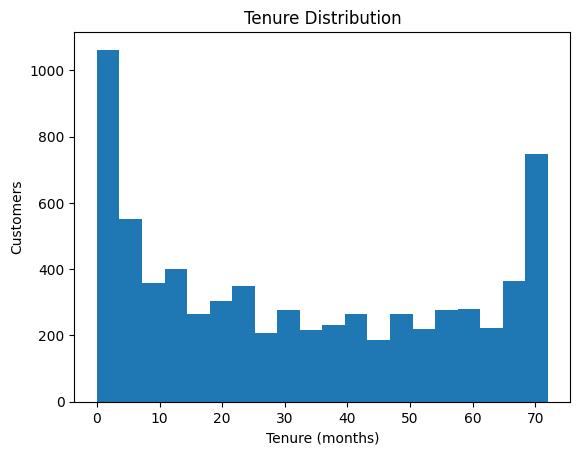

In [11]:
import matplotlib.pyplot as plt

plt.hist(df['tenure'], bins=20)
plt.xlabel('Tenure (months)')
plt.ylabel('Customers')
plt.title('Tenure Distribution')
plt.show()

In [12]:
df['tenure'].value_counts().sort_index().head(15)

,count
tenure,
0,11
1,613
2,238
3,200
4,176
5,133
6,110
7,131
8,123


In [13]:
df.groupby('tenure')['is_churned'].mean().head(15)

,is_churned
tenure,
0,0.000000
1,0.619902
2,0.516807
3,0.470000
4,0.471591
5,0.481203
6,0.363636
7,0.389313
8,0.341463




---
**ลูกค้าที่มี tenure ต่ำ โดยเฉพาะช่วงเดือนแรก ๆ มี Churn Rate สูง และแนวโน้มโดยรวมลดลงเมื่อ tenure เพิ่มขึ้น**


In [14]:
df.groupby('tenure_group')['is_churned'].mean()

,is_churned
tenure_group,
0_12_months,0.474382
13_24_months,0.287109
25_48_months,0.203890
over_48_months,0.095132


In [15]:
df.groupby('charge_bucket')['is_churned'].mean()

,is_churned
charge_bucket,
High,0.339835
Low,0.157367
Medium,0.289006


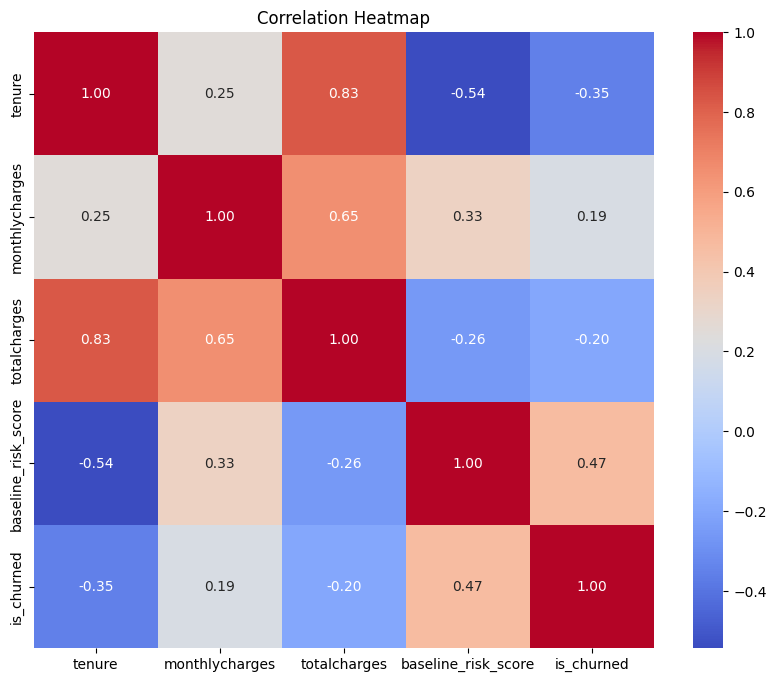

In [16]:
import seaborn as sns

numeric_cols = ['tenure', 'monthlycharges', 'totalcharges', 'baseline_risk_score', 'is_churned']
df_numeric=df[numeric_cols]

corr_matrix = df_numeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

ทำ Encode

In [17]:
colr_to_drop=['customerid','totalcharges']
df_model=df.drop(columns=colr_to_drop)
df_encode=pd.get_dummies(df_model,drop_first=True)

df_encoded = df_encode.astype(float)
print(f"จำนวน Features ทั้งหมดพร้อมเทรน: {df_encoded.shape[1]} คอลัมน์")
display(df_encoded.head())

จำนวน Features ทั้งหมดพร้อมเทรน: 20 คอลัมน์


,seniorcitizen,tenure,monthlycharges,is_churned,baseline_risk_score,gender_Male,partner_Yes,dependents_Yes,internetservice_Fiber optic,internetservice_No,contract_One year,contract_Two year,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check,tenure_group_13_24_months,tenure_group_25_48_months,tenure_group_over_48_months,charge_bucket_Low,charge_bucket_Medium
0,0.0,1.0,29.85,0.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,34.0,56.95,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,0.0,2.0,53.85,1.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.0,45.0,42.30,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.0,2.0,70.70,1.0,5.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

X = df_encoded.drop(columns=['is_churned'])
y = df_encoded['is_churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print(f"ขนาดของ Train Set สำหรับสอนโมเดล: {X_train_scaled.shape}")
print(f"ขนาดของ Test Set สำหรับทดสอบโมเดล: {X_test_scaled.shape}")

ขนาดของ Train Set สำหรับสอนโมเดล: (5634, 19)
ขนาดของ Test Set สำหรับทดสอบโมเดล: (1409, 19)


กำลังค้นหา Hyperparameter ที่ดีที่สุด...
Fitting 5 folds for each of 144 candidates, totalling 720 fits

Best Parameters: {'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Best CV Recall: 0.8161

Top 5 by recall — เทียบ trade-off กับ metric อื่น:
    mean_test_recall  mean_test_precision  mean_test_f1  mean_test_roc_auc  \
1              0.816                0.509         0.627              0.839   
10             0.816                0.509         0.627              0.839   
11             0.815                0.508         0.626              0.839   
2              0.815                0.508         0.626              0.839   
83             0.815                0.507         0.625              0.839   

    mean_test_avg_precision  
1                     0.636  
10                    0.636  
11                    0.636  
2                     0.636  
83                    0.635  
Classification Report (ผลสอบของโมเดล):
 

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_1449/1188077434.py:83: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1449/1188077434.py:83: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1449/1188077434.py:83: U

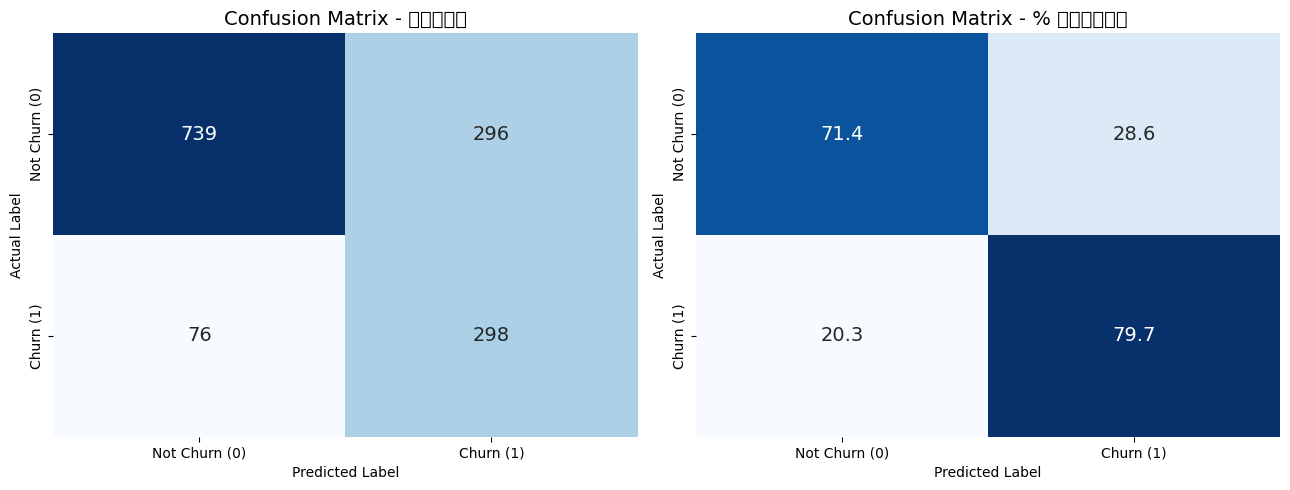

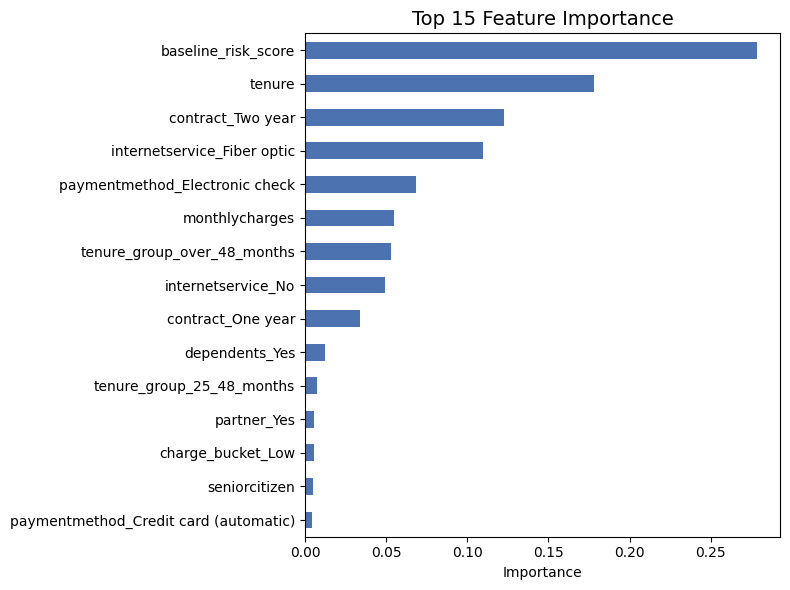

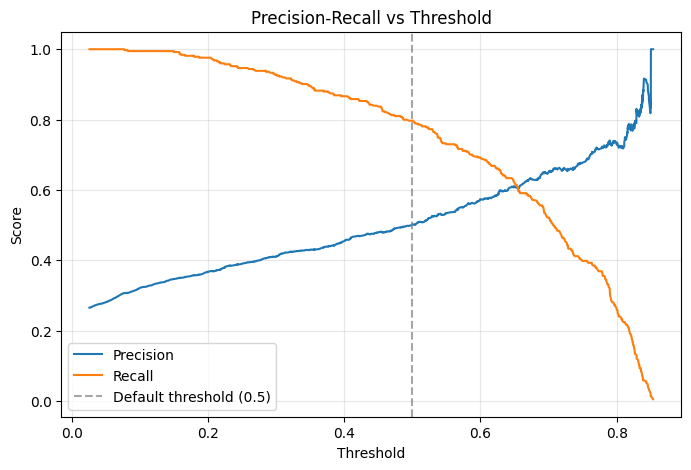

Threshold แนะนำ (recall >= 0.8): 0.487
-> Precision: 0.496 | Recall: 0.802


In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],                    # ใหม่: คุม feature ต่อการแตกกิ่ง ลด overfit ได้อีกทาง (จุดที่ 5)
    'class_weight': ['balanced', 'balanced_subsample']   # ลองเทียบ 2 แบบ ว่าอันไหนเวิร์คกว่าสำหรับ dataset นี้
}

rf_model = RandomForestClassifier(random_state=42)

# Track หลาย metric พร้อมกัน เพื่อเห็น trade-off ไม่ใช่มองแค่ recall เพียวๆ (จุดที่ 1)
scoring = {
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'avg_precision': 'average_precision'   # PR-AUC สะท้อน performance บน imbalanced data ได้ตรงกว่า ROC-AUC
}

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring=scoring,
    refit='recall',       # ยังยึด recall เป็นตัวตัดสินหลัก ตามเป้าหมายเดิม
    n_jobs=-1,
    verbose=1
)

print("กำลังค้นหา Hyperparameter ที่ดีที่สุด...")
grid_search.fit(X_train, y_train)      # RF ไม่ต้อง scale -> ใช้ X_train ตรงๆ (คง column name ไว้ด้วย) (จุดที่ 3)

best_model = grid_search.best_estimator_
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Recall: {grid_search.best_score_:.4f}")

# เช็คว่าโมเดล recall สูงสุด แลก precision ไปเท่าไหร่
results_df = pd.DataFrame(grid_search.cv_results_)
print("\nTop 5 by recall — เทียบ trade-off กับ metric อื่น:")
print(results_df.sort_values('rank_test_recall')
      .head(5)[['mean_test_recall', 'mean_test_precision', 'mean_test_f1',
                 'mean_test_roc_auc', 'mean_test_avg_precision']]
      .round(3))

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Classification Report (ผลสอบของโมเดล):")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

cm = confusion_matrix(y_test, y_pred)
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn (0)', 'Churn (1)'],
            yticklabels=['Not Churn (0)', 'Churn (1)'],
            cbar=False, annot_kws={"size": 14}, ax=axes[0])
axes[0].set_title('Confusion Matrix - จำนวน', fontsize=14)
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Not Churn (0)', 'Churn (1)'],
            yticklabels=['Not Churn (0)', 'Churn (1)'],
            cbar=False, annot_kws={"size": 14}, ax=axes[1])
axes[1].set_title('Confusion Matrix - % ต่อแถว', fontsize=14)
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Feature Importance (จุดที่ 4)
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='#4C72B0')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importance', fontsize=14)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Threshold tuning จาก precision-recall curve (จุดที่ 2)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Default threshold (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ตัวอย่าง: อยากได้ recall อย่างน้อย 80% -> หา threshold ที่ precision ดีที่สุดในกลุ่มที่ recall ยังผ่านเกณฑ์
target_recall = 0.80
valid_idx = np.where(recalls[:-1] >= target_recall)[0]
if len(valid_idx) > 0:
    best_idx = valid_idx[np.argmax(precisions[:-1][valid_idx])]
    print(f"Threshold แนะนำ (recall >= {target_recall}): {thresholds[best_idx]:.3f}")
    print(f"-> Precision: {precisions[best_idx]:.3f} | Recall: {recalls[best_idx]:.3f}")
else:
    print(f"ไม่มี threshold ไหนให้ recall >= {target_recall} ลองลด target ลง")

In [26]:
X_train_no_score = X_train.drop(columns=['baseline_risk_score'])
X_test_no_score = X_test.drop(columns=['baseline_risk_score'])

from sklearn.ensemble import RandomForestClassifier
model_no_score = RandomForestClassifier(**grid_search.best_params_, random_state=42)
model_no_score.fit(X_train_no_score, y_train)

from sklearn.metrics import classification_report
y_pred_no_score = model_no_score.predict(X_test_no_score)
print("ไม่มี baseline_risk_score:")
print(classification_report(y_test, y_pred_no_score))

ไม่มี baseline_risk_score:
              precision    recall  f1-score   support

         0.0       0.90      0.73      0.81      1035
         1.0       0.51      0.79      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



test model

In [25]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import pandas as pd

# ตัวไหน import ไม่ได้ (ยังไม่ได้ลง) จะข้ามไปเฉยๆ ไม่พัง
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}

try:
    from xgboost import XGBClassifier
    # scale_pos_weight = สัดส่วน negative/positive ช่วยเรื่อง imbalance คล้าย class_weight
    spw = (y_train == 0).sum() / (y_train == 1).sum()
    models['XGBoost'] = XGBClassifier(scale_pos_weight=spw, eval_metric='logloss', random_state=42)
except ImportError:
    print("XGBoost ยังไม่ได้ติดตั้ง -> pip install xgboost ถ้าอยากลอง")

try:
    from lightgbm import LGBMClassifier
    models['LightGBM'] = LGBMClassifier(class_weight='balanced', random_state=42, verbosity=-1)
except ImportError:
    print("LightGBM ยังไม่ได้ติดตั้ง -> pip install lightgbm ถ้าอยากลอง")

scoring = {'recall': 'recall', 'precision': 'precision', 'f1': 'f1',
           'roc_auc': 'roc_auc', 'avg_precision': 'average_precision'}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    results.append({
        'Model': name,
        'Recall': scores['test_recall'].mean(),
        'Precision': scores['test_precision'].mean(),
        'F1': scores['test_f1'].mean(),
        'ROC-AUC': scores['test_roc_auc'].mean(),
        'PR-AUC': scores['test_avg_precision'].mean(),
    })

comparison_df = pd.DataFrame(results).sort_values('Recall', ascending=False)
print(comparison_df.round(3).to_string(index=False))

              Model  Recall  Precision    F1  ROC-AUC  PR-AUC
Logistic Regression   0.791      0.509 0.619    0.840   0.634
           LightGBM   0.759      0.527 0.622    0.831   0.625
            XGBoost   0.672      0.535 0.595    0.818   0.601
  Gradient Boosting   0.505      0.651 0.568    0.841   0.644
      Random Forest   0.480      0.613 0.537    0.812   0.586
